In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = sns.load_dataset('tips')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [4]:
df.sample(5)

,total_bill,tip,sex,smoker,day,time,size
64,17.59,2.64,Male,No,Sat,Dinner,3
148,9.78,1.73,Male,No,Thur,Lunch,2
138,16.00,2.00,Male,Yes,Thur,Lunch,2
169,10.63,2.00,Female,Yes,Sat,Dinner,2
117,10.65,1.50,Female,No,Thur,Lunch,2


In [5]:
df_titanic = sns.load_dataset('titanic')

In [6]:
df_titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [8]:
print("bonjour")

bonjour


In [10]:
print ( df['total_bill'].mean(), 
df['total_bill'].median(), 
df['total_bill'].mode(), 
df['total_bill'].std(), 
df['total_bill'].var(), 
df['total_bill'].min(),
df['total_bill'].max()) 

19.78594262295082 17.795 0    13.42
Name: total_bill, dtype: float64 8.902411954856856 79.25293861397827 3.07 50.81


In [13]:
print(df[df['total_bill']==0])

Empty DataFrame
Columns: [total_bill, tip, sex, smoker, day, time, size]
Index: []


In [14]:
print(df) 

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


In [20]:
print(f"\n pourboir moyen : {df['tip'].mean() :.2f}$")
print(f"\n pourboir médian : {df['tip'].median() :.2f}$")
print(f"\n pourboir mode : {df['tip'].mode()[0] :.2f}$")


 pourboir moyen : 3.00$

 pourboir médian : 2.90$

 pourboir mode : 2.00$


In [21]:
for i in df.columns:
    print(f"\n {i} : {df['tip'].mean():.2f}")


 total_bill : 3.00

 tip : 3.00

 sex : 3.00

 smoker : 3.00

 day : 3.00

 time : 3.00

 size : 3.00


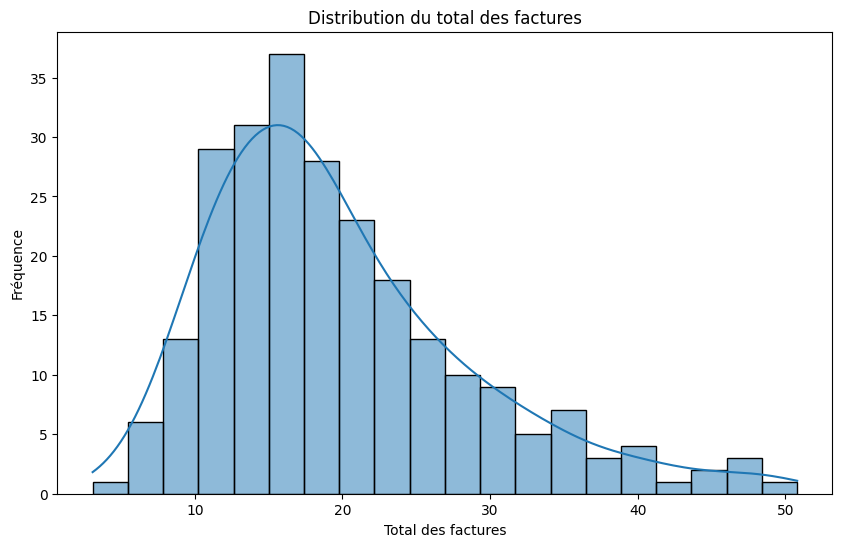

In [22]:
fig, size = plt.subplots(figsize=(10, 6))
sns.histplot(df['total_bill'], bins=20, kde=True)
plt.title('Distribution du total des factures')
plt.xlabel('Total des factures')
plt.ylabel('Fréquence')
plt.show()

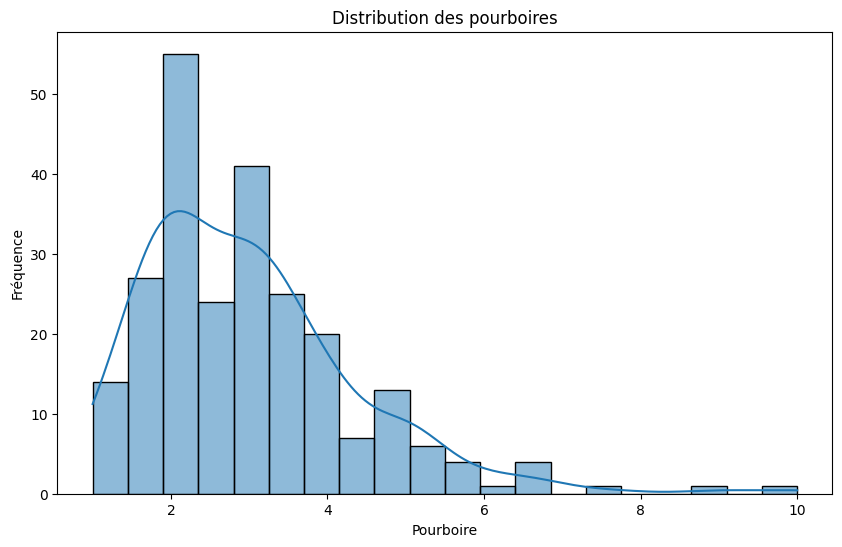

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df['tip'], bins=20, kde=True, ax=ax)
plt.title('Distribution des pourboires')
plt.xlabel('Pourboire')
plt.ylabel('Fréquence')
plt.show()

In [24]:
encodages = {
    "sex":    {"Male": 0, "Female": 1},
    "smoker": {"No": 0,   "Yes": 1},
    "time":   {"Lunch": 0,"Dinner": 1},
    "day":    {"Thur": 0, "Fri": 1, "Sat": 2, "Sun": 3},
}

In [25]:
df_ml = df.copy()
for col, mapping in encodages.items():
    df_ml[col + "_enc"] = df_ml[col].map(mapping)
    print(f"  ✅ {col} encodé : {mapping}")

  ✅ sex encodé : {'Male': 0, 'Female': 1}
  ✅ smoker encodé : {'No': 0, 'Yes': 1}
  ✅ time encodé : {'Lunch': 0, 'Dinner': 1}
  ✅ day encodé : {'Thur': 0, 'Fri': 1, 'Sat': 2, 'Sun': 3}


In [26]:
df_ml["addition_par_personne"] = df_ml["total_bill"] / df_ml["size"]
df_ml["est_weekend"]           = df_ml["day"].isin(["Sat","Sun"]).astype(int)
df_ml["total_bill_log"]        = np.log1p(df_ml["total_bill"])
df_ml["grande_table"]          = (df_ml["size"] >= 4).astype(int)
 

In [27]:
# ── 3.3 Sélection des features finales
FEATURES = [
    "total_bill", "total_bill_log", "size",
    "sex_enc", "smoker_enc", "day_enc", "time_enc",
    "addition_par_personne", "est_weekend", "grande_table"
]
TARGET = "tip"

In [28]:
X = df_ml[FEATURES]
y = df_ml[TARGET]
print(f"\n  📐 X : {X.shape}  |  y : {y.shape}")
print(f"  Features : {FEATURES}")


  📐 X : (244, 10)  |  y : (244,)
  Features : ['total_bill', 'total_bill_log', 'size', 'sex_enc', 'smoker_enc', 'day_enc', 'time_enc', 'addition_par_personne', 'est_weekend', 'grande_table']


In [30]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
 

In [35]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\n  🧪 x_train : {len(x_train)}  |  x_test : {len(x_test)}")
print(f"  🧪 y_train : {len(y_train)}  |  y_test : {len(y_test)}")


  🧪 x_train : 195  |  x_test : 49
  🧪 y_train : 195  |  y_test : 49


In [36]:
sclaer = StandardScaler()
x_train_scaled = sclaer.fit_transform(x_train)
x_test_scaled  = sclaer.transform(x_test)

In [37]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

In [40]:
resutlats = {}
for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    cv   = cross_val_score(model, x_train_scaled, y_train, cv=5, scoring="r2").mean()
    
    resutlats[name] = {
        "modele": model,
        "y_pred": y_pred,
        "MAE": mae,
        "R²": r2,
        "CV_R²": cv
    }
    print(f"\n  ✅ {name} : MAE={mae:.2f}, MSE={mse:.2f}, R²={r2:.2f}")


  ✅ Linear Regression : MAE=0.67, MSE=0.71, R²=0.43

  ✅ Ridge Regression : MAE=0.67, MSE=0.70, R²=0.44

  ✅ Lasso Regression : MAE=0.65, MSE=0.61, R²=0.51

  ✅ Decision Tree : MAE=0.83, MSE=1.31, R²=-0.05

  ✅ Random Forest : MAE=0.77, MSE=0.92, R²=0.27

  ✅ Gradient Boosting : MAE=0.80, MSE=0.99, R²=0.20


🏆 Meilleur modèle : Lasso Regression  (R²=0.5102)


Text(0.5, 0.98, 'ÉVALUATION DES MODÈLES — Prédiction de Pourboire')

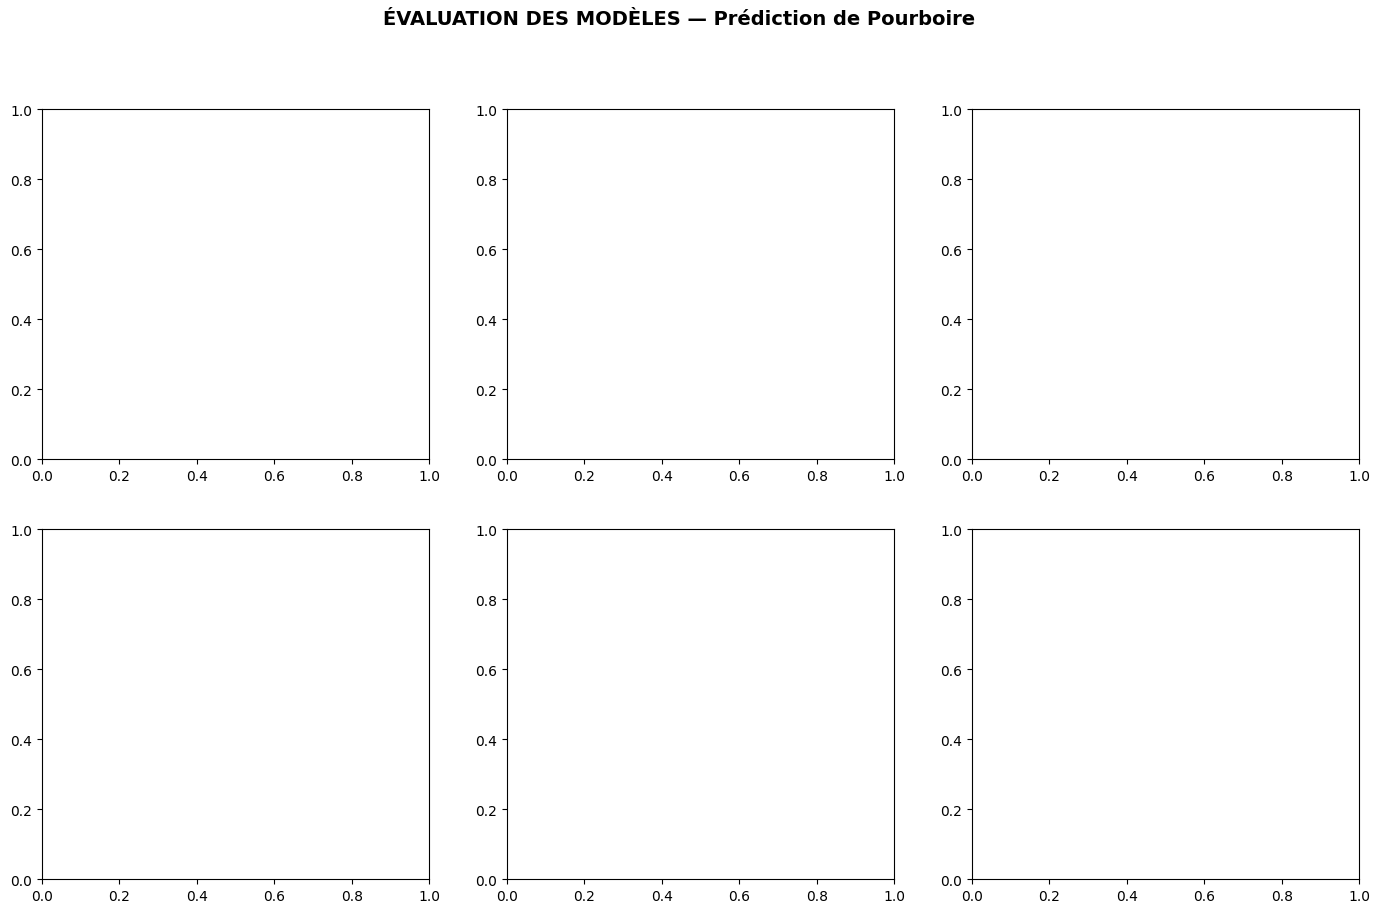

In [42]:
meilleur = max(resutlats, key=lambda k: resutlats[k]["R²"])
print(f"🏆 Meilleur modèle : {meilleur}  (R²={resutlats[meilleur]['R²']:.4f})")
 
COULEURS_M = ["#3498db","#e67e22","#e74c3c","#9b59b6","#2ecc71","#1abc9c"]
 
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("ÉVALUATION DES MODÈLES — Prédiction de Pourboire",
             fontsize=14, fontweight="bold")
 